# 04. SHAP Explainability

This notebook applies SHAP analysis to interpret the LightGBM credit default prediction model. The goal is to explain which features the model considers important and how those features contribute to predicted default risk. By visualizing feature importance and individual prediction explanations, this notebook helps make the model’s decision-making process more transparent and interpretable.


In [1]:
import os, gc, warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    roc_auc_score, average_precision_score,
    precision_score, recall_score, f1_score,
    confusion_matrix, classification_report
)
from lightgbm import LGBMClassifier

pd.set_option("display.max_columns", 200)

os.makedirs("/kaggle/working/figures", exist_ok=True)
os.makedirs("/kaggle/working/results", exist_ok=True)

In [2]:
try:
    import shap
except ImportError:
    !pip install shap -q
    import shap

In [3]:
def find_file(filename):
    for dirname, _, filenames in os.walk("/kaggle/input"):
        if filename in filenames:
            return os.path.join(dirname, filename)
    raise FileNotFoundError(f"{filename} not found. Add AMEX datasets to Kaggle input.")

train_path = find_file("train_data_f32.ftr")

print("train_path:", train_path)

train_path: /kaggle/input/datasets/munumbutt/amexfeather/train_data_f32.ftr


In [4]:
def recall_at_top_k(y_true, y_pred_proba, k=0.04):
    y_true = pd.Series(y_true).reset_index(drop=True)
    y_pred_proba = pd.Series(y_pred_proba).reset_index(drop=True)

    n_top = max(1, int(len(y_pred_proba) * k))
    top_idx = y_pred_proba.sort_values(ascending=False).head(n_top).index

    return y_true.loc[top_idx].sum() / y_true.sum()


def evaluate_model(model_name, y_true, y_pred_proba, threshold=0.5):
    y_pred = (y_pred_proba >= threshold).astype(int)

    result = {
        "model": model_name,
        "roc_auc": roc_auc_score(y_true, y_pred_proba),
        "pr_auc": average_precision_score(y_true, y_pred_proba),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "f1": f1_score(y_true, y_pred, zero_division=0),
        "recall_at_top_4pct": recall_at_top_k(y_true, y_pred_proba, k=0.04)
    }

    print(f"Model: {model_name}")
    for k, v in result.items():
        if k != "model":
            print(f"{k}: {v:.6f}")

    print("\nConfusion Matrix")
    print(confusion_matrix(y_true, y_pred))

    print("\nClassification Report")
    print(classification_report(y_true, y_pred, zero_division=0))

    return result

In [5]:
CAT_COLS = [
    "B_30", "B_38",
    "D_114", "D_116", "D_117", "D_120", "D_126",
    "D_63", "D_64", "D_66", "D_68"
]

def build_aggregated_dataset(train_path):
    train = pd.read_feather(train_path)

    train["S_2"] = pd.to_datetime(train["S_2"])
    train = train.sort_values(["customer_ID", "S_2"])

    num_cols = train.select_dtypes(include=[np.number]).columns.tolist()
    num_cols = [c for c in num_cols if c not in CAT_COLS + ["target"]]

    agg_num = train.groupby("customer_ID")[num_cols].agg(
        ["mean", "std", "min", "max", "last"]
    )

    agg_num.columns = ["_".join(col) for col in agg_num.columns]
    agg_num = agg_num.reset_index()

    existing_cat_cols = [c for c in CAT_COLS if c in train.columns]

    if existing_cat_cols:
        agg_cat = train.groupby("customer_ID")[existing_cat_cols].last().reset_index()
        agg_cat.columns = ["customer_ID"] + [f"{c}_last" for c in existing_cat_cols]
        data = agg_num.merge(agg_cat, on="customer_ID", how="left")
    else:
        data = agg_num.copy()

    statement_count = train.groupby("customer_ID").size().reset_index(name="statement_count")
    data = data.merge(statement_count, on="customer_ID", how="left")

    target = train.groupby("customer_ID")["target"].last().reset_index()
    data = data.merge(target, on="customer_ID", how="left")

    del train
    gc.collect()

    return data

In [6]:
data_agg = build_aggregated_dataset(train_path)

print("data_agg:", data_agg.shape)
print("target columns:", [col for col in data_agg.columns if "target" in col])
print("missing target:", data_agg["target"].isna().sum())

display(data_agg.head())

def encode_aggregated_categoricals(df):
    df = df.copy()
    cat_last_cols = [f"{c}_last" for c in CAT_COLS if f"{c}_last" in df.columns]

    for col in cat_last_cols:
        df[col] = df[col].astype("category").cat.codes.astype("int16")

    return df

X = data_agg.drop(columns=["customer_ID", "target"])
X = encode_aggregated_categoricals(X)

y = data_agg["target"].astype(int)

X_train, X_valid, y_train, y_valid = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(X_train.shape)
print(X_valid.shape)

data_agg: (458913, 899)
target columns: ['target']
missing target: 0


,customer_ID,P_2_mean,P_2_std,P_2_min,P_2_max,P_2_last,D_39_mean,D_39_std,D_39_min,D_39_max,D_39_last,B_1_mean,B_1_std,B_1_min,B_1_max,B_1_last,B_2_mean,B_2_std,B_2_min,B_2_max,B_2_last,R_1_mean,R_1_std,R_1_min,R_1_max,R_1_last,S_3_mean,S_3_std,S_3_min,S_3_max,S_3_last,D_41_mean,D_41_std,D_41_min,D_41_max,D_41_last,B_3_mean,B_3_std,B_3_min,B_3_max,B_3_last,D_42_mean,D_42_std,D_42_min,D_42_max,D_42_last,D_43_mean,D_43_std,D_43_min,D_43_max,D_43_last,D_44_mean,D_44_std,D_44_min,D_44_max,D_44_last,B_4_mean,B_4_std,B_4_min,B_4_max,B_4_last,D_45_mean,D_45_std,D_45_min,D_45_max,D_45_last,B_5_mean,B_5_std,B_5_min,B_5_max,B_5_last,R_2_mean,R_2_std,R_2_min,R_2_max,R_2_last,D_46_mean,D_46_std,D_46_min,D_46_max,D_46_last,D_47_mean,D_47_std,D_47_min,D_47_max,D_47_last,D_48_mean,D_48_std,D_48_min,D_48_max,D_48_last,D_49_mean,D_49_std,D_49_min,D_49_max,D_49_last,B_6_mean,B_6_std,B_6_min,B_6_max,...,B_42_max,B_42_last,D_130_mean,D_130_std,D_130_min,D_130_max,D_130_last,D_131_mean,D_131_std,D_131_min,D_131_max,D_131_last,D_132_mean,D_132_std,D_132_min,D_132_max,D_132_last,D_133_mean,D_133_std,D_133_min,D_133_max,D_133_last,R_28_mean,R_28_std,R_28_min,R_28_max,R_28_last,D_134_mean,D_134_std,D_134_min,D_134_max,D_134_last,D_135_mean,D_135_std,D_135_min,D_135_max,D_135_last,D_136_mean,D_136_std,D_136_min,D_136_max,D_136_last,D_137_mean,D_137_std,D_137_min,D_137_max,D_137_last,D_138_mean,D_138_std,D_138_min,D_138_max,D_138_last,D_139_mean,D_139_std,D_139_min,D_139_max,D_139_last,D_140_mean,D_140_std,D_140_min,D_140_max,D_140_last,D_141_mean,D_141_std,D_141_min,D_141_max,D_141_last,D_142_mean,D_142_std,D_142_min,D_142_max,D_142_last,D_143_mean,D_143_std,D_143_min,D_143_max,D_143_last,D_144_mean,D_144_std,D_144_min,D_144_max,D_144_last,D_145_mean,D_145_std,D_145_min,D_145_max,D_145_last,B_30_last,B_38_last,D_114_last,D_116_last,D_117_last,D_120_last,D_126_last,D_63_last,D_64_last,D_66_last,D_68_last,statement_count,target
0,3249127622875,1.003573,0.001341,1.002345,1.005004,1.005004,0.088271,0.200800,0.000390,0.621244,0.008411,0.008108,0.004341,0.000974,0.014857,0.005660,0.932826,0.097657,0.811644,1.009668,1.009403,0.005930,0.002705,0.001177,0.008771,0.007339,0.140968,0.044033,0.091621,0.224990,0.179448,0.004832,0.002766,0.000953,0.009718,0.004560,0.009518,0.005056,0.001070,0.018145,0.004012,NaN,NaN,NaN,NaN,NaN,0.114842,0.058349,0.043479,0.242577,0.107345,0.004525,0.003595,0.000957,0.008145,0.004473,0.008952,0.010414,0.001463,0.034932,0.028382,0.552715,0.010112,0.538817,0.569654,0.567501,0.007017,0.003436,0.002249,0.014812,0.008377,0.004572,0.002587,0.000477,0.009146,0.005527,NaN,NaN,NaN,NaN,NaN,0.438815,0.105067,0.378035,0.626452,0.620382,0.065910,0.012214,0.052290,0.075891,0.052290,NaN,NaN,NaN,NaN,NaN,2.070536,4.545935,0.195590,12.316238,...,NaN,NaN,0.005106,0.003222,0.000651,0.009623,0.005780,0.004079,0.003460,0.000794,0.009910,0.001284,NaN,NaN,NaN,NaN,NaN,0.006001,0.002713,0.000846,0.009912,0.004446,0.004149,0.003131,0.000385,0.009797,0.006051,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.005535,0.003037,0.000708,0.009517,0.006212,0.005252,0.003065,0.000966,0.009469,0.003949,0.005050,0.003300,0.000266,0.009407,0.006435,NaN,NaN,NaN,NaN,NaN,0.003673,0.003183,0.000143,0.008928,0.000439,0.005934,0.003247,0.000510,0.009815,0.000895,0.005011,0.002883,0.000674,0.008520,0.006147,0.0,2.0,1.0,0.0,4.0,1.0,1.0,CO,,NaN,6.0,13,0
1,23402014749356,0.415518,0.100825,0.188222,0.498842,0.215565,0.100123,0.136302,0.005283,0.441647,0.030713,0.569637,0.173722,0.461963,0.878662,0.872928,0.024636,0.003400,0.020004,0.029966,0.020936,0.330217,0.425201,0.000543,1.002690,1.002117,0.364866,0.125289,0.206318,0.650284,0.402358,0.004804,0.003160,0.001181,0.009746,0.001812,0.651621,0.127401,0.511142,0.851680,0.851680,NaN,NaN,NaN,NaN,NaN,1.209194,0.310234,0.604089,1.648602,0.985836,0.130363,0.002732,0.126324,0.134471,0.127954,0.143859,0.020630,0.118439,0.183084,0.163676,0.071888,0.009582,0.057746,0.087532,0.083874,0.012343,

(367130, 897)
(91783, 897)


In [7]:
lgbm_model = LGBMClassifier(
    n_estimators=1200,
    learning_rate=0.025,
    num_leaves=96,
    subsample=0.8,
    colsample_bytree=0.8,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

lgbm_model.fit(
    X_train,
    y_train,
    eval_set=[(X_valid, y_valid)],
    eval_metric="auc"
)

pred = lgbm_model.predict_proba(X_valid)[:, 1]

result = evaluate_model(
    "LightGBM - Aggregated Features for SHAP",
    y_valid,
    pred
)

pd.DataFrame([result]).to_csv(
    "/kaggle/working/results/04_shap_model_results.csv",
    index=False
)

with open("/kaggle/working/results/04_classification_report_lgbm.txt", "w") as f:
    f.write(classification_report(
        y_valid,
        (pred >= 0.5).astype(int),
        zero_division=0
    ))

[LightGBM] [Info] Number of positive: 95062, number of negative: 272068
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 6.840197 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 223279
[LightGBM] [Info] Number of data points in the train set: 367130, number of used features: 896
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Start training from score 0.000000
Model: LightGBM - Aggregated Features for SHAP
roc_auc: 0.961023
pr_auc: 0.897353
precision: 0.739017
recall: 0.905285
f1: 0.813745
recall_at_top_4pct: 0.153286

Confusion Matrix
[[60419  7598]
 [ 2251 21515]]

Classification Report
              precision    recall  f1-score   support

           0       0.96      0.89      0.92     68017
           1       0.74      0.91      0.81     23766

    accuracy                           0.89     91783
   macro avg       0.85      0.90      0.87     9178

,feature,importance
4,P_2_last,806
9,D_39_last,761
59,B_4_last,678
39,B_3_last,564
79,D_46_last,542
56,B_4_std,506
25,S_3_mean,495
49,D_43_last,492
29,S_3_last,488
69,B_5_last,442


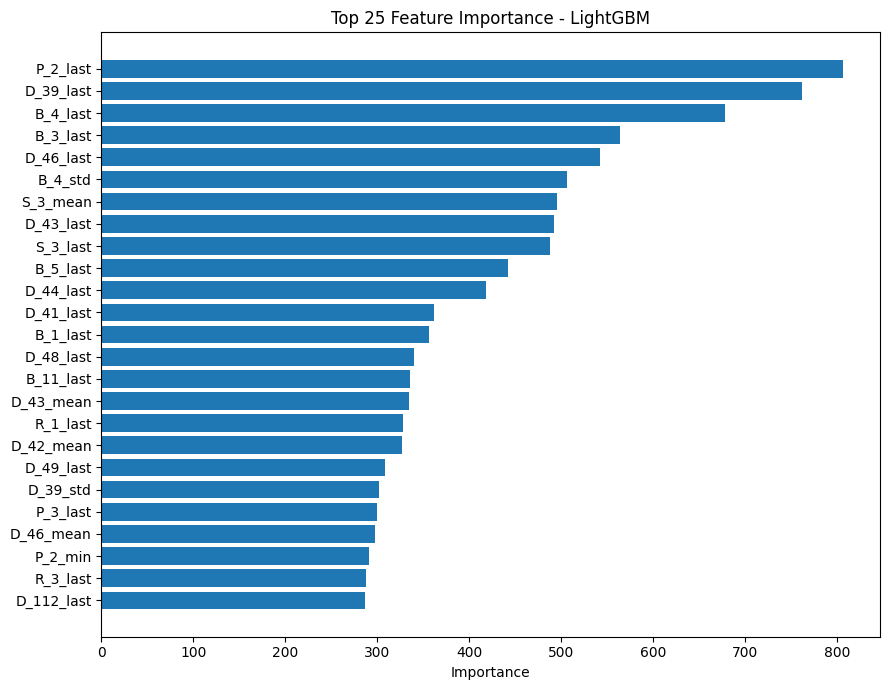

In [8]:
importance = pd.DataFrame({
    "feature": X_train.columns,
    "importance": lgbm_model.feature_importances_
}).sort_values("importance", ascending=False)

display(importance.head(25))

importance.to_csv("/kaggle/working/results/04_feature_importance.csv", index=False)

top = importance.head(25).sort_values("importance")

plt.figure(figsize=(9, 7))
plt.barh(top["feature"], top["importance"])
plt.title("Top 25 Feature Importance - LightGBM")
plt.xlabel("Importance")
plt.tight_layout()
plt.savefig("/kaggle/working/figures/04_feature_importance.png", dpi=300)
plt.show()

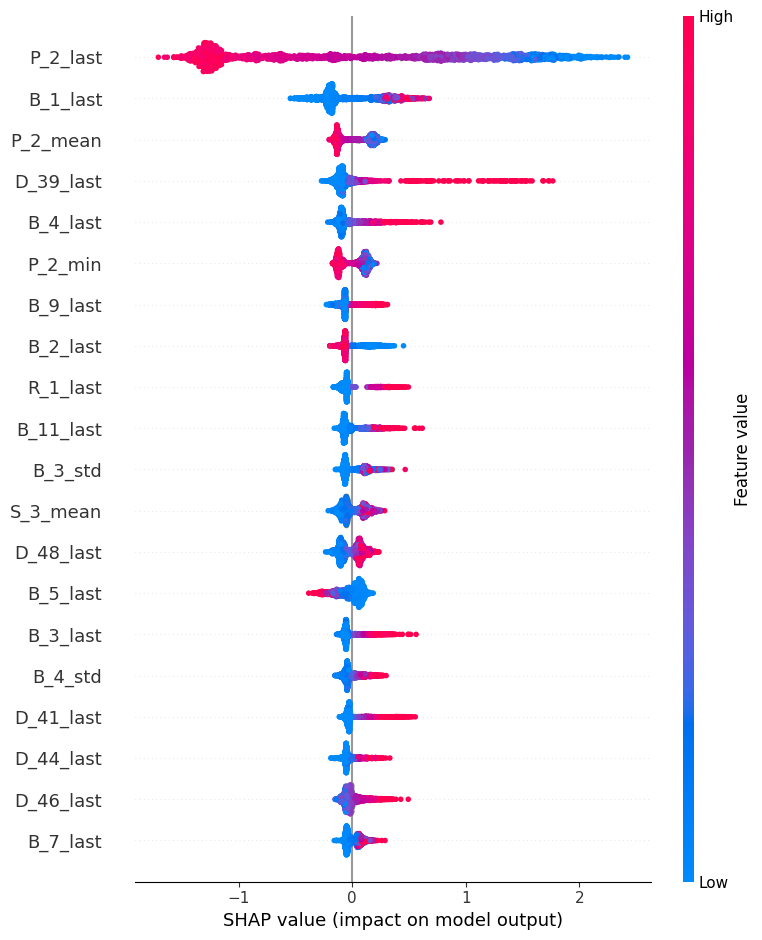

In [9]:
sample_size = min(2000, len(X_valid))
sample_X = X_valid.sample(sample_size, random_state=42)

explainer = shap.TreeExplainer(lgbm_model)
shap_values = explainer.shap_values(sample_X)

if isinstance(shap_values, list):
    shap_values = shap_values[1]

shap.summary_plot(shap_values, sample_X, max_display=20, show=False)
plt.tight_layout()
plt.savefig("/kaggle/working/figures/04_shap_summary.png", dpi=300, bbox_inches="tight")
plt.show()

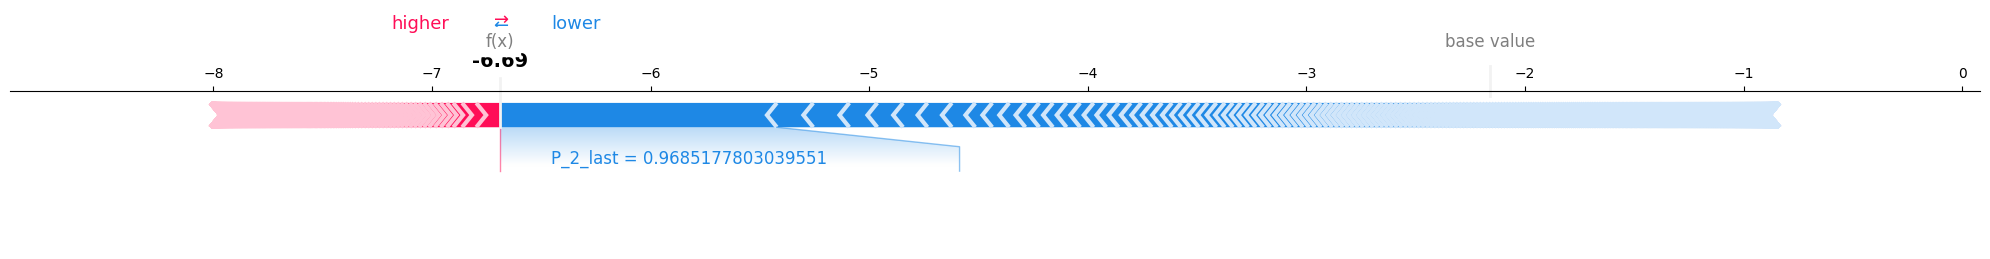

In [10]:
row_index = 0
single_customer = sample_X.iloc[[row_index]]

expected_value = (
    explainer.expected_value[1]
    if isinstance(explainer.expected_value, list)
    else explainer.expected_value
)

shap.force_plot(
    expected_value,
    shap_values[row_index, :],
    single_customer,
    matplotlib=True,
    show=False
)

plt.tight_layout()
plt.savefig("/kaggle/working/figures/04_shap_force_example.png", dpi=300, bbox_inches="tight")
plt.show()

In [11]:
import os

for dirname, _, filenames in os.walk("/kaggle/working/figures"):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/working/figures/04_shap_force_example.png
/kaggle/working/figures/04_feature_importance.png
/kaggle/working/figures/04_shap_summary.png


In [12]:
import os

fig_path = "/kaggle/working/figures/01_feature_importance_last_statement.png"

print("Figures folder exists?:", os.path.exists("/kaggle/working/figures"))
print("Figure file exists?:", os.path.exists(fig_path))

if os.path.exists(fig_path):
    print("File path:", fig_path)
    print("File size:", os.path.getsize(fig_path), "bytes")
else:
    print("The figure file has not been saved yet.")

Figures folder exists?: True
Figure file exists?: False
The figure file has not been saved yet.


In [13]:
import os

os.makedirs("/kaggle/working/figures", exist_ok=True)
os.makedirs("/kaggle/working/results", exist_ok=True)

print("Figures folder exists?:", os.path.exists("/kaggle/working/figures"))
print("Results folder exists?:", os.path.exists("/kaggle/working/results"))
print("Working folder:", os.listdir("/kaggle/working"))
print("Figures folder:", os.listdir("/kaggle/working/figures"))

Figures folder exists?: True
Results folder exists?: True
Working folder: ['.virtual_documents', 'figures', 'results']
Figures folder: ['04_shap_force_example.png', '04_feature_importance.png', '04_shap_summary.png']


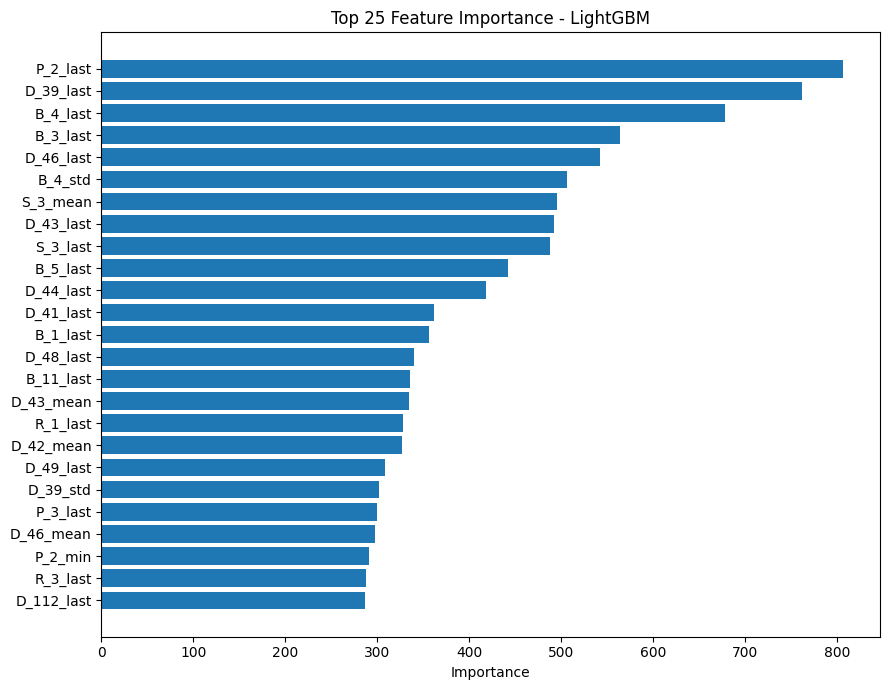

Figure file exists?: True
File size: 167642
Files in figures folder: ['04_shap_force_example.png', '04_feature_importance.png', '04_shap_summary.png']


In [14]:
import os
import pandas as pd
import matplotlib.pyplot as plt

os.makedirs("/kaggle/working/figures", exist_ok=True)

importance = pd.DataFrame({
    "feature": X_train.columns,
    "importance": lgbm_model.feature_importances_
}).sort_values("importance", ascending=False)

top = importance.head(25).sort_values("importance")

fig_path = "/kaggle/working/figures/04_feature_importance.png"

plt.figure(figsize=(9, 7))
plt.barh(top["feature"], top["importance"])
plt.title("Top 25 Feature Importance - LightGBM")
plt.xlabel("Importance")
plt.tight_layout()
plt.savefig(fig_path, dpi=300, bbox_inches="tight")
plt.show()

print("Figure file exists?:", os.path.exists(fig_path))
print("File size:", os.path.getsize(fig_path) if os.path.exists(fig_path) else "not found")
print("Files in figures folder:", os.listdir("/kaggle/working/figures"))